(3, 7500)


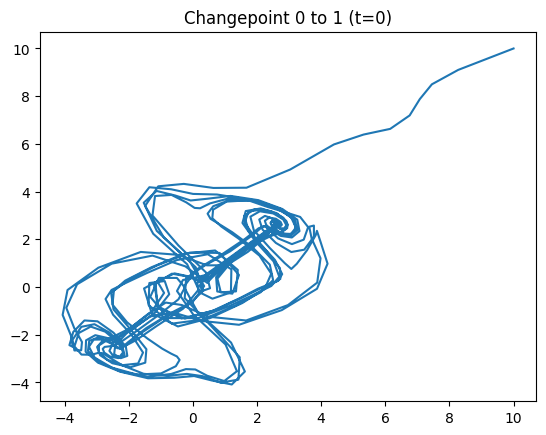

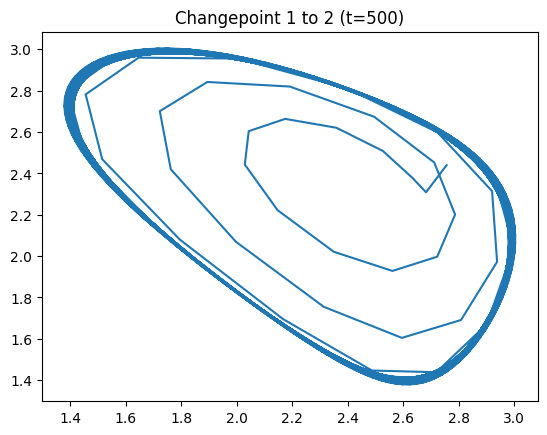

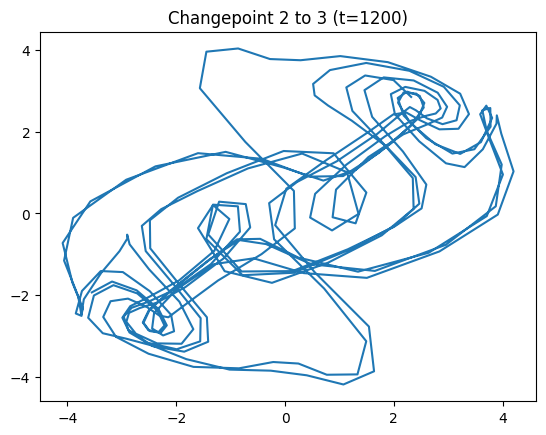

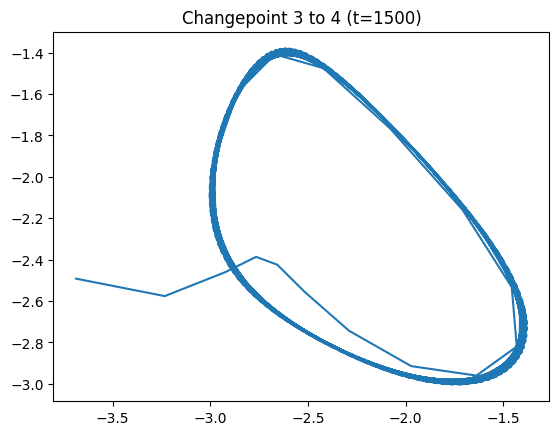

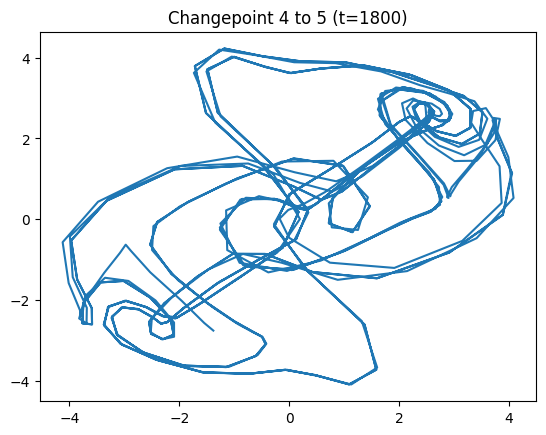

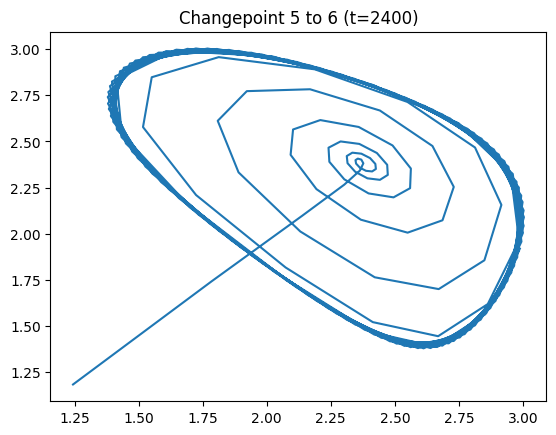

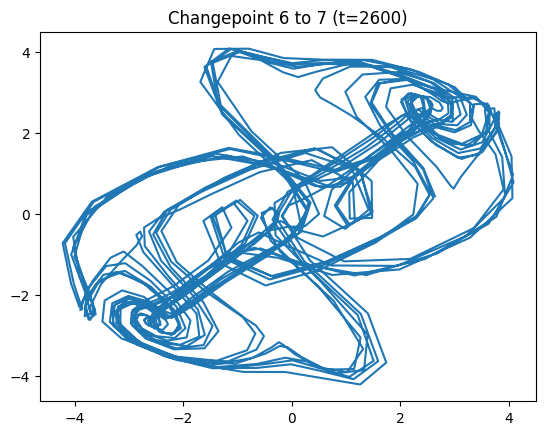

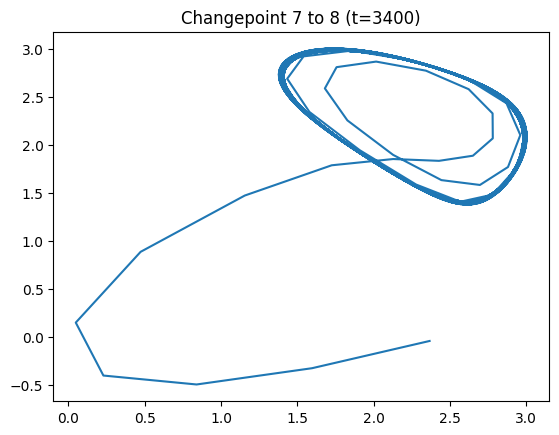

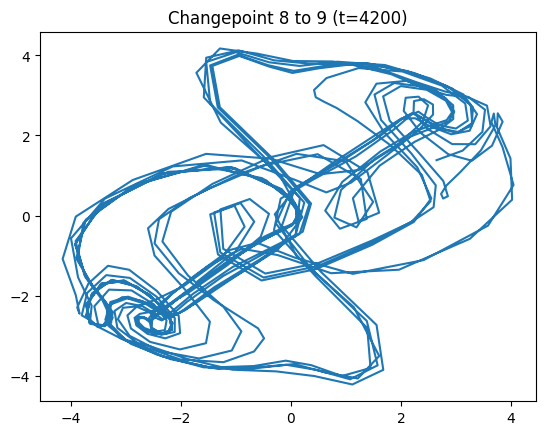

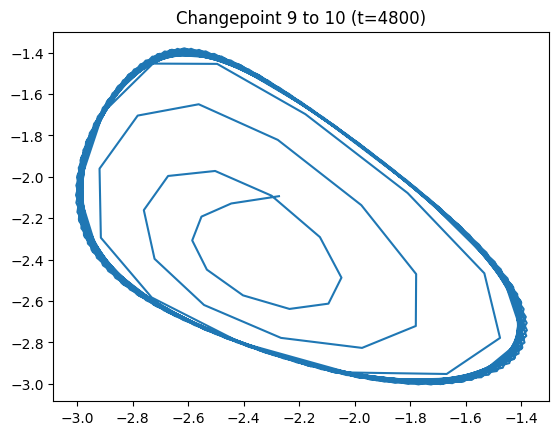

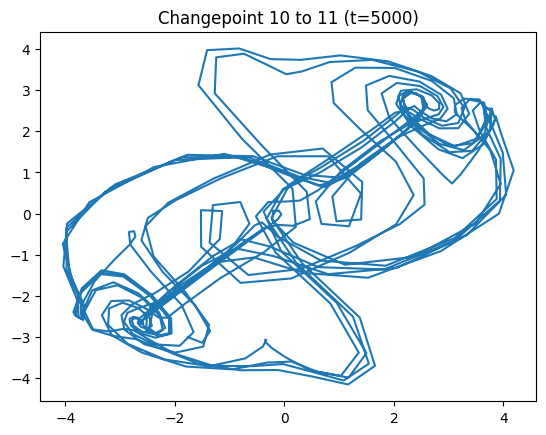

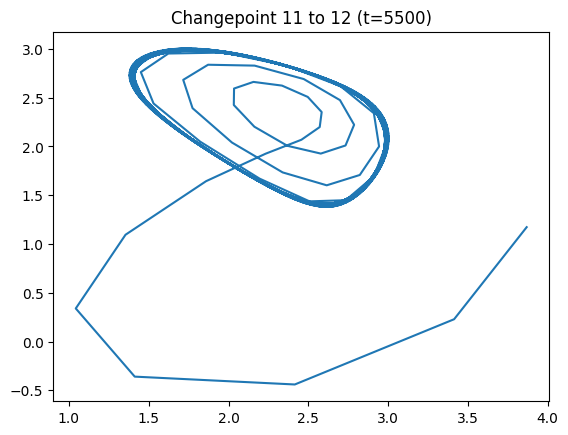

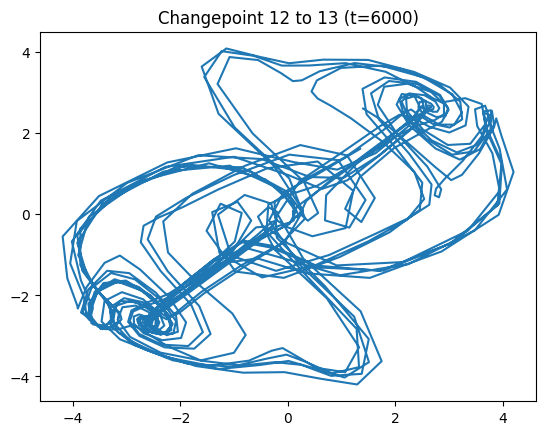

In [1]:
# Load data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

exp = pd.read_csv("../data/thomas.csv",header=None)
train_input = exp.to_numpy().transpose()[1:,:-1] # of shape (spatial dimensions x time)
print(train_input.shape)

changetimes=np.array((0,500,1200,1500,1800,2400,2600,3400,4200,4800,5000,5500,6000,6700))

# test_data = pd.read_csv("../data/thomas_periodic_orbit.csv",header=None)
# test_data = test_data.to_numpy().transpose()[1:,:-1]
# print(test_data.shape)

for i in range(len(changetimes) - 1):
    plt.plot(train_input[0, changetimes[i]:changetimes[i + 1]], train_input[1, changetimes[i]:changetimes[i + 1]])
    plt.title("Changepoint %d to %d (t=%d)" % (i, i+1, changetimes[i]))
    plt.show()

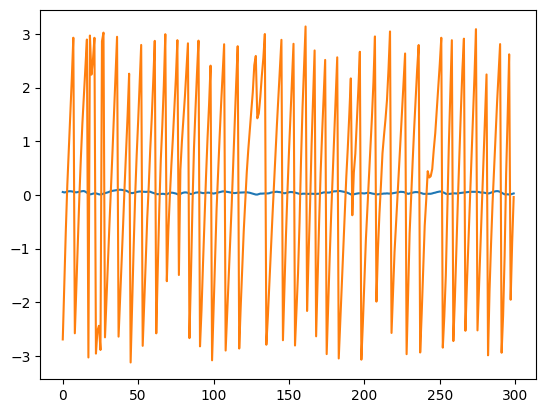

G:\My Drive\Research\Losert Lab\Projects\Algorithms\rhythmic_sharing\src\spike_sharing.py:222: RuntimeWarning: Mean of empty slice
  z = np.nanmean(np.exp(1j * np.asarray(self.link_phase_history)), axis=1)


R_target = 0.0418
Cross (t=501): prev_r = 0.0398, r = 0.0502
Getting initial frozen phase: 8.60% undefined


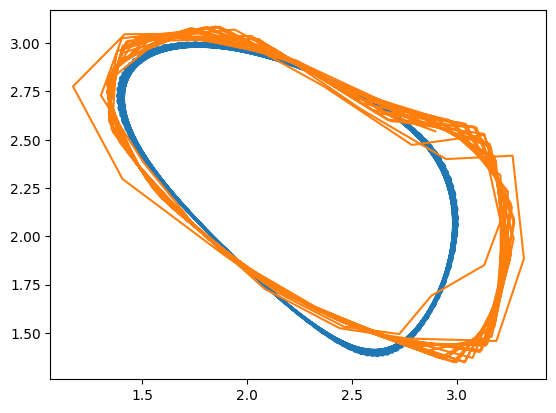

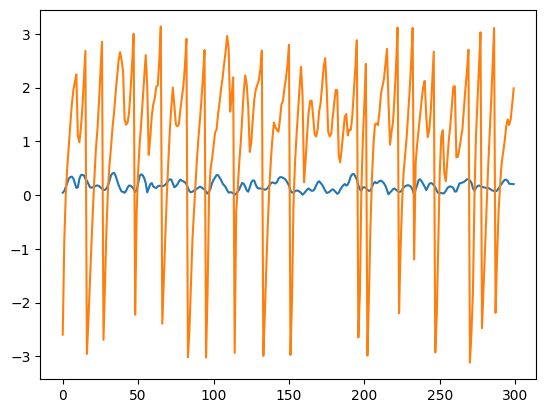

G:\My Drive\Research\Losert Lab\Projects\Algorithms\rhythmic_sharing\src\spike_sharing.py:222: RuntimeWarning: Mean of empty slice
  z = np.nanmean(np.exp(1j * np.asarray(self.link_phase_history)), axis=1)


R_target = 0.1832
Cross (t=403): prev_r = 0.1972, r = 0.1423
Getting initial frozen phase: 0.00% undefined


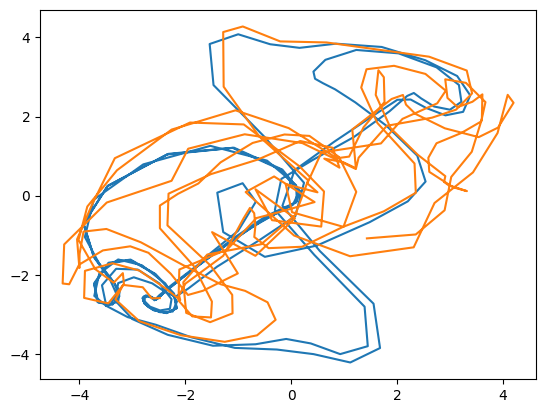

In [2]:
# Initialize network and train/predict on data to first and second changepoints
from rhythmic_sharing import RhythmicNetwork
from spike_sharing import SpikingNetwork

omega0 = 0.5

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=omega0
)

network.train(train_input[:, 500:1000], warmup_time=200)

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.show()

pred = network.predict(train_input[:, 500:1200], warmup_time=500)
plt.plot(train_input[0, 1000:1200], train_input[1, 1000:1200])
plt.plot(pred[0, :], pred[1, :])
plt.show()

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=omega0
)

network.train(train_input[:, 4200:4600], warmup_time=100)

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.show()

pred = network.predict(train_input[:, 4200:4800], warmup_time=400)
plt.plot(train_input[0, 4600:4800], train_input[1, 4600:4800])
plt.plot(pred[0, :], pred[1, :])
plt.show()

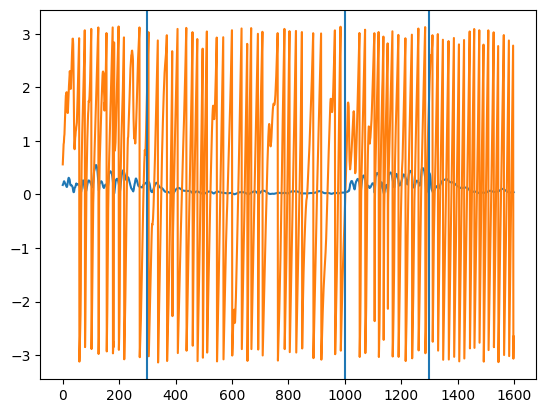

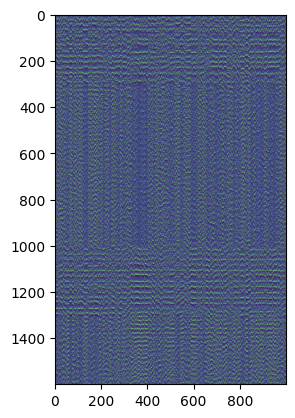

G:\My Drive\Research\Losert Lab\Projects\Algorithms\rhythmic_sharing\src\spike_sharing.py:222: RuntimeWarning: Mean of empty slice
  z = np.nanmean(np.exp(1j * np.asarray(self.link_phase_history)), axis=1)


R_target = 0.2539
Cross (t=417): prev_r = 0.2349, r = 0.2762
Getting initial frozen phase: 0.00% undefined


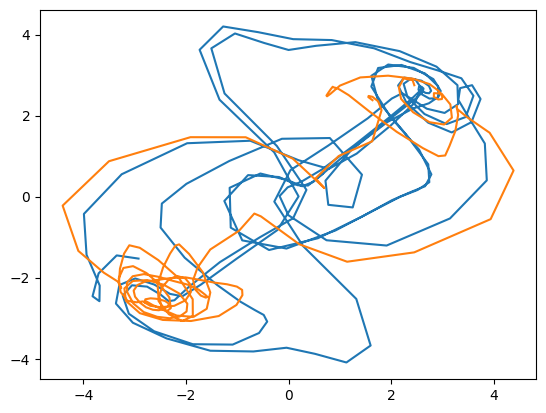

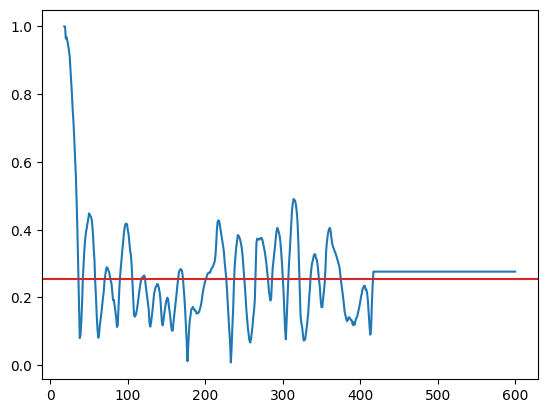

In [ ]:
# Train on multiple dynamics and predict multiple dynamics

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=0.2,
    link_coupling=0
)

network.train(train_input[:, :1800], warmup_time=200)

plt.plot(np.asarray(network.get_global_parameters()).T)
plt.axvline(1300)
plt.axvline(1000)
plt.axvline(300)
plt.show()

plt.imshow(np.asarray(network.link_states_history)[:, :, 0])
plt.show()

pred = network.predict(train_input[:, 1800:2400], warmup_time=400)
plt.plot(train_input[0, 2200:2400], train_input[1, 2200:2400])
plt.plot(pred[0, :], pred[1, :])
plt.show()

plt.plot(np.asarray(network.get_global_parameters()).T[:, 0])
plt.axhline(network.r_target, color="tab:red")
plt.show()

pred = network.predict(train_input[:, 3400:4200], warmup_time=400)
plt.plot(train_input[0, 3800:4200], train_input[1, 3800:4200])
plt.plot(pred[0, :], pred[1, :])
plt.show()

plt.plot(np.asarray(network.get_global_parameters()).T[:, 0])
plt.axhline(network.r_target, color="tab:red")
plt.show()

In [ ]:
from lm_neuron_eq import clip_voltage

c = network.link_strength_change_ratio
modulation = lambda v: 1 - c * clip_voltage(v)

network = SpikingNetwork(
    input_dims=3,
    spectral_radius=0.6,
    input_weight=120e-2,
    average_degree_nodes=10,
    num_nodes=100,
    leakage=0,
    omega0=0.2,
    link_coupling=0
)

network.train(train_input[:, :1800], warmup_time=200)

train_links = np.asarray(network.link_states_history)        # (T, num_links, 2)
offset = 200                                                  # training warmup_time
settle = int(2 * 2 * np.pi / network.omega0)                  # skip the transient after each changepoint
periodic = slice(500 - offset + settle, 1200 - offset)        # absolute 500:1200
chaotic  = slice(1200 - offset + settle, 1500 - offset)       # absolute 1200:1500, for contrast

m_per = modulation(train_links[periodic, :, 0])               # (T_seg, num_links)
m_cha = modulation(train_links[chaotic, :, 0])

pred = network.predict(train_input[:, 3400:4200], warmup_time=400)

m_frozen = modulation(np.asarray(network.link_states_history)[-1][:, 0])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bins = np.linspace(1 - c, 1, 41)

axes[0].hist(m_per.ravel(), bins, density=True, alpha=0.5, label="train periodic (instantaneous)")
axes[0].hist(m_cha.ravel(), bins, density=True, alpha=0.5, label="train chaotic (instantaneous)")
axes[0].hist(m_frozen, bins, density=True, histtype="step", lw=2, color="k", label="frozen")
axes[0].set_title("Modulation, all links"); axes[0].legend()

axes[1].hist(m_per.mean(axis=0), bins, density=True, alpha=0.5, label="train periodic (per-link mean)")
axes[1].hist(m_frozen, bins, density=True, histtype="step", lw=2, color="k", label="frozen")
axes[1].set_title("Per-link time average vs frozen"); axes[1].legend()

axes[2].scatter(m_per.mean(axis=0), m_frozen, s=4, alpha=0.5)
axes[2].plot([1 - c, 1], [1 - c, 1], "r--")
axes[2].set_xlabel("training mean (periodic)"); axes[2].set_ylabel("frozen")
axes[2].set_title("Per-link")
plt.tight_layout(); plt.show()